In [2]:
# %% [markdown]
# # Team 3 - Linear vs Softmax vs Sparse vs Flash Attention (Colab benchmark)
#
# Follows the corrected PDCA workbook: **S** standard softmax, **K** explicit kernel (small checks only), **L** reordered linear attention, plus **Sparse** (local block-sparse) and **Flash/SDPA** (exact, fused).
#
# **How to run:** `Runtime -> Change runtime type -> GPU (T4 is fine)`, then `Runtime -> Run all`.
# Everything is PyTorch only (already installed in Colab). Total runtime is roughly 5-15 min on a T4.
#
# | Method | Exact softmax? | Time | Memory (intermediate) |
# |---|---|---|---|
# | Softmax (naive) | yes | O(N^2 d) | O(N^2) |
# | Flash / SDPA | yes | O(N^2 d) | O(N) |
# | Sparse (local window w) | no - only nearby keys | O(N w d) | O(N w) |
# | Linear (kernel, reordered) | no - different kernel | O(N r d_v) | O(r d_v) state |
#
# Section map: 0 setup -> 1 implementations -> 2 correctness checks -> 3 efficiency scaling (N grows gradually until OOM) -> 4 output deviation -> 5 retrieval with distractors -> 6 dimension sweep -> 7 overall comparison + acceptance test.

# %%


In [5]:
import math, time, gc, warnings
import numpy as np, pandas as pd, torch, torch.nn.functional as F
import matplotlib.pyplot as plt
warnings.filterwarnings("ignore")
pd.set_option("display.width", 200); pd.set_option("display.max_columns", 30)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
GPU = torch.cuda.get_device_name(0) if DEVICE == "cuda" else "CPU only (memory columns will be NaN - use a GPU runtime)"

CFG = dict(
    B=1, H=4, DK=64, DV=64,            # fixed dims (batch, heads, d_k, d_v); feature dim r = DK for ReLU+1
    WINDOW=64,                          # sparse: block size w, each query sees 3w keys (own + neighbour blocks)
    DTYPE=torch.float32,                # set torch.float16 on an Ampere+ GPU (A100/L4) to get the real FlashAttention kernel
    LENGTHS=[64,256,512,1024,2048,4096,8192,16384,32768,65536] if DEVICE=="cuda" else [64,256,512,1024,2048,4096],
    WARMUP=3, REPEATS=10, MAX_SEC=5.0,  # stop growing a method once its median latency exceeds MAX_SEC
    EVAL_LENGTHS=[64,256,1024,4096], SCALES=[0.5,1.0,2.0], SEEDS=[0,1,2,3,4],   # output-deviation experiment
    RET_LENGTHS=[64,256,512,1024,2048,4096], RET_TASKS=20,                       # retrieval experiment
    N_CLASSES=16, KEY_SCALE=12.0, QUERY_NOISE=0.3,
    DELTA=0.05, SPEED_TARGET=2.0,       # non-inferiority margin (accuracy) and required speedup vs the naive softmax
    EPS=1e-6,
)
B,H,DK,DV,W = CFG["B"],CFG["H"],CFG["DK"],CFG["DV"],CFG["WINDOW"]
DTYPE, EPS = CFG["DTYPE"], CFG["EPS"]
print("torch", torch.__version__, "| device:", DEVICE, "|", GPU, "| dtype:", DTYPE)

torch 2.11.0+cu128 | device: cuda | Tesla T4 | dtype: torch.float32


In [6]:
def phi(x):                       # feature map from the workbook: ReLU(x)+1  (strictly positive)
    return F.relu(x) + 1.0

# --- S: standard scaled softmax attention (baseline, materialises the N x N matrix) ---
def softmax_attention(Q, K, V):
    s = (Q @ K.transpose(-1, -2)) / math.sqrt(Q.shape[-1])
    return torch.softmax(s, dim=-1) @ V

# --- K: explicit kernel attention  phi(Q) phi(K)^T, normalised (N x N, for SMALL correctness checks only) ---
def explicit_kernel_attention(Q, K, V, feat=phi):
    A = feat(Q) @ feat(K).transpose(-1, -2)
    A = A / (A.sum(-1, keepdim=True) + EPS)
    return A @ V

# --- L: reordered linear attention  phi(Q) (phi(K)^T V) / (phi(Q) phi(K)^T 1)  (never builds N x N) ---
def linear_attention(Q, K, V, feat=phi):
    acc = torch.float32 if Q.dtype in (torch.float16, torch.bfloat16) else Q.dtype   # fp32 accumulators for half inputs (fp16 overflows when summing over N)
    fq, fk = feat(Q).to(acc), feat(K).to(acc)
    kv  = fk.transpose(-1, -2) @ V.to(acc)             # (B,H,r,dv)  fixed-size state
    z   = fk.sum(-2, keepdim=True).transpose(-1, -2)   # (B,H,r,1)   phi(K)^T 1
    num = fq @ kv                                      # (B,H,N,dv)
    den = fq @ z + EPS                                 # (B,H,N,1)   scalar per query, broadcast over dv
    return (num / den).to(V.dtype)

# --- Causal versions (used only in the leakage test) ---
def causal_softmax_attention(Q, K, V):
    N = Q.shape[-2]
    s = (Q @ K.transpose(-1, -2)) / math.sqrt(Q.shape[-1])
    s = s.masked_fill(torch.triu(torch.ones(N, N, dtype=torch.bool, device=Q.device), 1), float("-inf"))
    return torch.softmax(s, -1) @ V

def causal_linear_attention(Q, K, V):                  # prefix sums, test-scale only (stores N*r*dv)
    fq, fk = phi(Q), phi(K)
    kv  = torch.einsum("bhnr,bhnd->bhnrd", fk, V).cumsum(2)
    z   = fk.cumsum(2)
    num = torch.einsum("bhnr,bhnrd->bhnd", fq, kv)
    return num / ((fq * z).sum(-1, keepdim=True) + EPS)

# --- Sparse: local block-sparse attention. Each query block attends to previous, own and next block (3w keys). ---
def sparse_local_attention(Q, K, V, w=W):
    Bq, Hq, N, _ = Q.shape
    nb = math.ceil(N / w); Np = nb * w; pad = Np - N
    def blocks(x):
        if pad: x = F.pad(x, (0, 0, 0, pad))
        return x.reshape(Bq, Hq, nb, w, x.shape[-1])
    def with_neighbours(xb):                            # (B,H,nb,w,d) -> (B,H,nb,3w,d)
        xp = F.pad(xb, (0, 0, 0, 0, 1, 1))
        return torch.cat([xp[:, :, :-2], xp[:, :, 1:-1], xp[:, :, 2:]], dim=3)
    Qb, Kn, Vn = blocks(Q), with_neighbours(blocks(K)), with_neighbours(blocks(V))
    valid = torch.zeros(nb + 2, w, dtype=torch.bool, device=Q.device)      # which key slots are real tokens
    valid[1:-1] = (torch.arange(Np, device=Q.device) < N).reshape(nb, w)
    mask = torch.cat([valid[:-2], valid[1:-1], valid[2:]], dim=1)          # (nb,3w)
    s = (Qb @ Kn.transpose(-1, -2)) / math.sqrt(Q.shape[-1])               # (B,H,nb,w,3w)
    s = s.masked_fill(~mask[None, None, :, None, :], float("-inf"))
    out = torch.softmax(s, -1) @ Vn                                        # (B,H,nb,w,dv)
    return out.reshape(Bq, Hq, Np, -1)[:, :, :N]

# --- Flash / SDPA: exact attention through PyTorch's fused kernels. We record WHICH backend really runs. ---
try:
    from torch.nn.attention import sdpa_kernel, SDPBackend
    HAVE_SDPA_CTX = True
except Exception:
    HAVE_SDPA_CTX = False
_BACKEND = {}
def resolve_backend(dtype, device):
    key = (dtype, device)
    if key in _BACKEND: return _BACKEND[key]
    if not HAVE_SDPA_CTX:
        _BACKEND[key] = ("DEFAULT (old torch)", None); return _BACKEND[key]
    t = torch.randn(1, 2, 128, 64, device=device, dtype=dtype)
    for name, be in [("FLASH", SDPBackend.FLASH_ATTENTION), ("EFFICIENT (mem-efficient exact)", SDPBackend.EFFICIENT_ATTENTION)]:
        try:
            with sdpa_kernel(be): F.scaled_dot_product_attention(t, t, t)
            if device == "cuda": torch.cuda.synchronize()
            _BACKEND[key] = (name, be); return _BACKEND[key]
        except Exception:
            continue
    _BACKEND[key] = ("MATH (fallback - not fused)", SDPBackend.MATH); return _BACKEND[key]

def flash_attention(Q, K, V):
    name, be = resolve_backend(Q.dtype, Q.device.type)
    if be is None: return F.scaled_dot_product_attention(Q, K, V)
    with sdpa_kernel(be): return F.scaled_dot_product_attention(Q, K, V)

METHODS = {"softmax (naive)": softmax_attention, "linear (ReLU+1)": linear_attention,
           f"sparse (local w={W})": sparse_local_attention, "flash/SDPA (exact)": flash_attention}
SOFT, LIN, SPARSE, FLASH = list(METHODS)
print("Flash/SDPA backend actually selected for", DTYPE, "->", resolve_backend(DTYPE, DEVICE)[0])
if DEVICE == "cuda" and resolve_backend(DTYPE, DEVICE)[0].startswith("EFFICIENT"):
    print("Note: true FlashAttention needs an Ampere+ GPU and fp16/bf16. On T4 you get the memory-efficient exact kernel (same idea: exact, no stored N x N).")

Flash/SDPA backend actually selected for torch.float32 -> EFFICIENT (mem-efficient exact)
Note: true FlashAttention needs an Ampere+ GPU and fp16/bf16. On T4 you get the memory-efficient exact kernel (same idea: exact, no stored N x N).


In [7]:
d64 = torch.float64
Q3 = torch.tensor([[1,2],[2,1],[1,1]], dtype=d64)[None,None]
K3 = torch.tensor([[1,0],[0,1],[1,1]], dtype=d64)[None,None]
V3 = torch.tensor([[10,0],[0,10],[5,5]], dtype=d64)[None,None]
print("QK^T (correct)      :", (Q3 @ K3.transpose(-1,-2))[0,0].tolist())
print("phi(Q)phi(K)^T      :", (phi(Q3) @ phi(K3).transpose(-1,-2))[0,0].tolist(), " <- the 'reported' matrix (mapped inputs)")
unscaled  = torch.softmax(Q3 @ K3.transpose(-1,-2), -1) @ V3
mapped_un = torch.softmax(phi(Q3) @ phi(K3).transpose(-1,-2), -1) @ V3
rows = {"scaled softmax":   softmax_attention(Q3,K3,V3)[0,0,0],
        "unscaled softmax": unscaled[0,0,0],
        "mapped unscaled":  mapped_un[0,0,0],
        "linear (L)":       linear_attention(Q3,K3,V3)[0,0,0],
        "explicit kernel (K)": explicit_kernel_attention(Q3,K3,V3)[0,0,0]}
for k,v in rows.items(): print(f"{k:22s} first row = {[round(x,6) for x in v.tolist()]}")
assert torch.allclose(rows["scaled softmax"], torch.tensor([4.280169,5.719831],dtype=d64), atol=1e-5)
assert torch.allclose(rows["linear (L)"], torch.tensor([4.8,5.2],dtype=d64), atol=1e-5)

def rel_err(a, ref): return ((a - ref).norm() / ref.norm().clamp_min(1e-12)).item()
g = torch.Generator().manual_seed(0)
cases = {"random": torch.randn(2,3,50,16,generator=g,dtype=d64), "zeros": torch.zeros(2,3,50,16,dtype=d64),
         "negative": -3*torch.rand(2,3,50,16,generator=g,dtype=d64), "single token": torch.randn(2,3,1,16,generator=g,dtype=d64)}
print("\nK (explicit N x N) vs L (reordered) - should agree to float64 precision:")
for name, x in cases.items():
    Vv = torch.randn(x.shape[0],x.shape[1],x.shape[2],7,generator=g,dtype=d64)      # d_v != d_k on purpose
    a, b = explicit_kernel_attention(x,x.flip(-1),Vv), linear_attention(x,x.flip(-1),Vv)
    ok = torch.isfinite(b).all().item() and torch.allclose(a,b,atol=1e-9,rtol=1e-9)
    print(f"  {name:13s} max|K-L| = {(a-b).abs().max().item():.2e}  finite={torch.isfinite(b).all().item()}  ->", "PASS" if ok else "FAIL")
    assert ok

print("\nCausal leakage test (change FUTURE keys/values -> earlier outputs must not change):")
Qc,Kc,Vc = (torch.randn(1,2,40,16,generator=g,dtype=d64) for _ in range(3)); t0 = 25
K2, V2 = Kc.clone(), Vc.clone(); K2[:,:,t0:] += torch.randn_like(K2[:,:,t0:]); V2[:,:,t0:] += torch.randn_like(V2[:,:,t0:])
for name, fn in [("causal softmax", causal_softmax_attention), ("causal linear", causal_linear_attention)]:
    diff = (fn(Qc,Kc,Vc)[:,:,:t0] - fn(Qc,K2,V2)[:,:,:t0]).abs().max().item()
    print(f"  {name:15s} max change in outputs before t={t0}: {diff:.2e} ->", "PASS" if diff < 1e-12 else "LEAK")
    assert diff < 1e-12
full = linear_attention(Qc,Kc,Vc); full2 = linear_attention(Qc,K2,V2)
print(f"  (non-causal linear, for contrast) change before t={t0}: {(full-full2)[:,:,:t0].abs().max().item():.2e}  <- leaks, as expected")

x = torch.randn(1,H,300,DK); v = torch.randn(1,H,300,DV)
print("\nSparse with window >= N must equal softmax:", torch.allclose(sparse_local_attention(x,x,v,w=512), softmax_attention(x,x,v), atol=1e-5))
print("Flash/SDPA vs softmax (fp32):", f"{rel_err(flash_attention(x,x,v), softmax_attention(x,x,v)):.2e}")


QK^T (correct)      : [[1.0, 2.0, 3.0], [2.0, 1.0, 3.0], [1.0, 1.0, 2.0]]
phi(Q)phi(K)^T      : [[7.0, 8.0, 10.0], [8.0, 7.0, 10.0], [6.0, 6.0, 8.0]]  <- the 'reported' matrix (mapped inputs)
scaled softmax         first row = [4.280169, 5.719831]
unscaled softmax       first row = [4.226511, 5.773489]
mapped unscaled        first row = [4.639074, 5.360926]
linear (L)             first row = [4.8, 5.2]
explicit kernel (K)    first row = [4.8, 5.2]

K (explicit N x N) vs L (reordered) - should agree to float64 precision:
  random        max|K-L| = 2.78e-16  finite=True  -> PASS
  zeros         max|K-L| = 2.78e-16  finite=True  -> PASS
  negative      max|K-L| = 1.94e-16  finite=True  -> PASS
  single token  max|K-L| = 4.44e-16  finite=True  -> PASS

Causal leakage test (change FUTURE keys/values -> earlier outputs must not change):
  causal softmax  max change in outputs before t=25: 0.00e+00 -> PASS
  causal linear   max change in outputs before t=25: 0.00e+00 -> PASS
  (non-causal lin

N=    64 done | softmax=0.31ms | linear=0.57ms | sparse=1.03ms | flash/SDPA=0.22ms
N=   256 done | softmax=0.27ms | linear=0.44ms | sparse=0.88ms | flash/SDPA=0.24ms
N=   512 done | softmax=0.38ms | linear=0.48ms | sparse=0.94ms | flash/SDPA=0.40ms
N=  1024 done | softmax=1.11ms | linear=0.39ms | sparse=0.69ms | flash/SDPA=1.00ms
N=  2048 done | softmax=3.28ms | linear=0.54ms | sparse=0.92ms | flash/SDPA=3.63ms
N=  4096 done | softmax=11.19ms | linear=0.86ms | sparse=1.38ms | flash/SDPA=9.81ms
N=  8192 done | softmax=37.38ms | linear=1.38ms | sparse=2.29ms | flash/SDPA=29.03ms
N= 16384 done | softmax=175.61ms | linear=4.01ms | sparse=5.32ms | flash/SDPA=113.95ms
N= 32768 done | linear=4.91ms | sparse=8.50ms | flash/SDPA=369.45ms
N= 65536 done | linear=9.74ms | sparse=16.86ms | flash/SDPA=1601.74ms

Median latency (ms):


method,softmax (naive),linear (ReLU+1),sparse (local w=64),flash/SDPA (exact)
N,,,,
64,0.307,0.572,1.031,0.221
256,0.272,0.442,0.876,0.244
512,0.384,0.480,0.940,0.401
1024,1.110,0.389,0.694,1.000
2048,3.279,0.541,0.919,3.631
4096,11.191,0.863,1.375,9.809
8192,37.383,1.385,2.294,29.031
16384,175.608,4.012,5.320,113.946
32768,NaN,4.905,8.497,369.448


Extra peak memory (MB, output + intermediates; inputs excluded):


method,softmax (naive),linear (ReLU+1),sparse (local w=64),flash/SDPA (exact)
N,,,,
64,0.2,0.3,0.8,0.1
256,2.2,1.1,3.3,0.2
512,8.5,2.1,6.5,0.5
1024,33.0,4.1,13.0,1.0
2048,130.0,8.1,26.0,2.0
4096,516.0,16.1,52.0,4.0
8192,2056.0,32.2,104.0,8.0
16384,8208.0,64.3,208.1,16.0
32768,NaN,128.6,416.1,32.0


Status per point (OOM / skipped are kept as results):


method,softmax (naive),linear (ReLU+1),sparse (local w=64),flash/SDPA (exact)
N,,,,
64,ok,ok,ok,ok
256,ok,ok,ok,ok
512,ok,ok,ok,ok
1024,ok,ok,ok,ok
2048,ok,ok,ok,ok
4096,ok,ok,ok,ok
8192,ok,ok,ok,ok
16384,ok,ok,ok,ok
32768,OOM,ok,ok,ok


Speedup = baseline_time / method_time  (>1 means method is faster):


,linear vs naive softmax,linear vs flash/SDPA,sparse vs naive softmax,sparse vs flash/SDPA
N,,,,
64,0.54,0.39,0.30,0.21
256,0.62,0.55,0.31,0.28
512,0.80,0.84,0.41,0.43
1024,2.86,2.57,1.60,1.44
2048,6.06,6.72,3.57,3.95
4096,12.97,11.36,8.14,7.13
8192,27.00,20.97,16.30,12.66
16384,43.77,28.40,33.01,21.42
32768,NaN,75.32,NaN,43.48


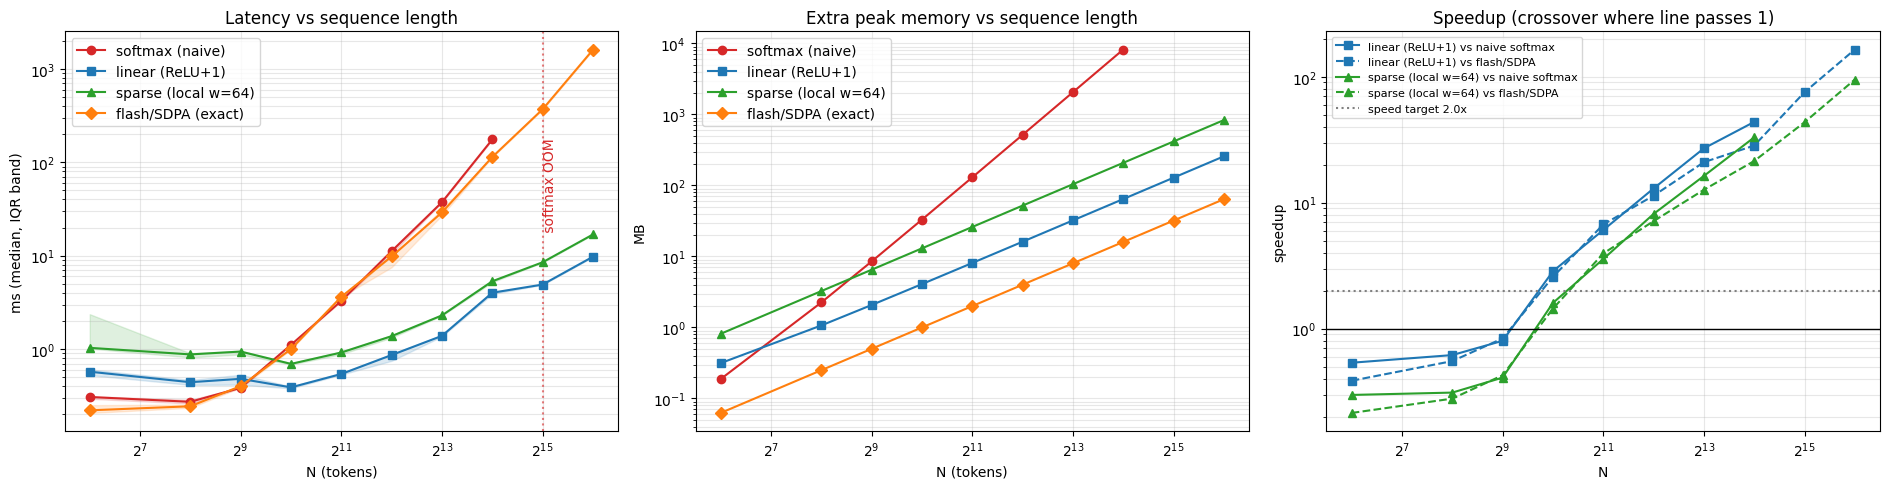

In [8]:
def sync():
    if DEVICE == "cuda": torch.cuda.synchronize()

def make_inputs(N, seed=0, dk=None, dv=None, dtype=None):
    dk, dv, dtype = dk or DK, dv or DV, dtype or DTYPE
    gen = torch.Generator().manual_seed(seed)
    f = lambda d: torch.randn(B, H, N, d, generator=gen).to(DEVICE, dtype)
    return f(dk), f(dk), f(dv)

def time_once(fn, Q, K, V):                     # ms; CUDA events with synchronisation (not async submit time)
    if DEVICE == "cuda":
        s, e = torch.cuda.Event(enable_timing=True), torch.cuda.Event(enable_timing=True)
        sync(); s.record(); out = fn(Q, K, V); e.record(); sync(); ms = s.elapsed_time(e)
    else:
        t = time.perf_counter(); out = fn(Q, K, V); ms = (time.perf_counter() - t) * 1e3
    del out; return ms

def peak_mem_mb(fn, Q, K, V):                   # allocated memory: (peak - inputs already resident); output + intermediates counted
    if DEVICE != "cuda": return float("nan"), float("nan")
    gc.collect(); torch.cuda.empty_cache(); sync()
    base = torch.cuda.memory_allocated(); torch.cuda.reset_peak_memory_stats()
    out = fn(Q, K, V); sync(); peak = torch.cuda.max_memory_allocated(); del out
    return (peak - base) / 2**20, peak / 2**20

def is_oom(e): return "out of memory" in str(e).lower()

def run_efficiency(lengths=CFG["LENGTHS"], methods=METHODS):
    rows, dead = [], {}                          # dead: method -> reason ("OOM" / "time cap")
    for N in lengths:
        Q, K, V = make_inputs(N)
        alive = [m for m in methods if m not in dead]
        for m in methods:                        # record unrun points explicitly
            if m in dead: rows.append(dict(N=N, method=m, status=f"skipped ({dead[m]})"))
        for m in list(alive):                    # warm-up (also detects OOM)
            try:
                for _ in range(CFG["WARMUP"]): methods[m](Q, K, V)
                sync()
            except RuntimeError as e:
                if not is_oom(e): raise
                dead[m] = "OOM"; alive.remove(m); rows.append(dict(N=N, method=m, status="OOM")); gc.collect()
                if DEVICE == "cuda": torch.cuda.empty_cache()
        times = {m: [] for m in alive}
        for _ in range(CFG["REPEATS"]):          # interleave methods to spread thermal / background effects
            for m in alive: times[m].append(time_once(methods[m], Q, K, V))
        for m in alive:
            t = np.array(times[m]); extra, peak = peak_mem_mb(methods[m], Q, K, V)
            rows.append(dict(N=N, method=m, status="ok", median_ms=np.median(t), q25_ms=np.quantile(t,.25),
                             q75_ms=np.quantile(t,.75), n=len(t), extra_mem_mb=extra, peak_total_mb=peak))
            if np.median(t) > CFG["MAX_SEC"] * 1e3: dead[m] = "time cap"
        print(f"N={N:>6} done | " + " | ".join(f"{m.split(' ')[0]}={np.median(times[m]):.2f}ms" for m in alive))
        del Q, K, V; gc.collect()
        if DEVICE == "cuda": torch.cuda.empty_cache()
    return pd.DataFrame(rows)

eff = run_efficiency()
lat = eff.pivot(index="N", columns="method", values="median_ms")[list(METHODS)]
mem = eff.pivot(index="N", columns="method", values="extra_mem_mb")[list(METHODS)]
status = eff.pivot(index="N", columns="method", values="status")[list(METHODS)]
print("\nMedian latency (ms):");            display(lat.round(3))
print("Extra peak memory (MB, output + intermediates; inputs excluded):"); display(mem.round(1))
print("Status per point (OOM / skipped are kept as results):"); display(status)
sp = pd.DataFrame({"linear vs naive softmax": lat[SOFT]/lat[LIN], "linear vs flash/SDPA": lat[FLASH]/lat[LIN],
                   "sparse vs naive softmax": lat[SOFT]/lat[SPARSE], "sparse vs flash/SDPA": lat[FLASH]/lat[SPARSE]})
print("Speedup = baseline_time / method_time  (>1 means method is faster):"); display(sp.round(2))

# %%
# ---- plots for section 3 ----
STY = {SOFT:("tab:red","o"), LIN:("tab:blue","s"), SPARSE:("tab:green","^"), FLASH:("tab:orange","D")}
fig, ax = plt.subplots(1, 3, figsize=(19, 5))
for m in METHODS:
    d = eff[(eff.method==m)&(eff.status=="ok")]; c, mk = STY[m]
    ax[0].plot(d.N, d.median_ms, marker=mk, color=c, label=m); ax[0].fill_between(d.N, d.q25_ms, d.q75_ms, color=c, alpha=.15)
    ax[1].plot(d.N, d.extra_mem_mb, marker=mk, color=c, label=m)
    o = eff[(eff.method==m)&(eff.status=="OOM")]
    for _, r in o.iterrows():
        ax[0].axvline(r.N, color=c, ls=":", alpha=.6); ax[0].text(r.N, ax[0].get_ylim()[1], f" {m.split(' ')[0]} OOM", color=c, rotation=90, va="top")
for a, t, yl in [(ax[0], "Latency vs sequence length", "ms (median, IQR band)"), (ax[1], "Extra peak memory vs sequence length", "MB")]:
    a.set_xscale("log", base=2); a.set_yscale("log"); a.set_xlabel("N (tokens)"); a.set_ylabel(yl); a.set_title(t); a.grid(alpha=.3, which="both"); a.legend()
for c in [LIN, SPARSE]:
    ax[2].plot(sp.index, lat[SOFT]/lat[c], marker=STY[c][1], color=STY[c][0], label=f"{c} vs naive softmax")
    ax[2].plot(sp.index, lat[FLASH]/lat[c], marker=STY[c][1], color=STY[c][0], ls="--", label=f"{c} vs flash/SDPA")
ax[2].axhline(1, color="k", lw=1); ax[2].axhline(CFG["SPEED_TARGET"], color="gray", ls=":", label=f"speed target {CFG['SPEED_TARGET']}x")
ax[2].set_xscale("log", base=2); ax[2].set_yscale("log"); ax[2].set_xlabel("N"); ax[2].set_ylabel("speedup"); ax[2].set_title("Speedup (crossover where line passes 1)")
ax[2].grid(alpha=.3, which="both"); ax[2].legend(fontsize=8)
plt.tight_layout(); plt.show()

In [9]:
def eval_inputs(N, seed, scale):
    gen = torch.Generator().manual_seed(seed)
    g = lambda d: torch.randn(B, H, N, d, generator=gen).to(DEVICE, torch.float32)
    return scale * g(DK), scale * g(DK), g(DV)         # scale changes logit magnitude (softmax sharpness)

rows = []
for N in CFG["EVAL_LENGTHS"]:
    for sc in CFG["SCALES"]:
        for sd in CFG["SEEDS"]:
            Q, K, V = eval_inputs(N, sd, sc); ref = softmax_attention(Q, K, V)
            for m in [LIN, SPARSE, FLASH]:
                rows.append(dict(N=N, scale=sc, seed=sd, method=m, rel_err=rel_err(METHODS[m](Q, K, V), ref)))
err = pd.DataFrame(rows)
tab = err.groupby(["method","N","scale"]).rel_err.agg(["mean","std"]).unstack("N")
print("Relative error vs exact softmax  (mean over 5 seeds; std in second block):"); display(tab["mean"].round(4)); display(tab["std"].round(4))

Relative error vs exact softmax  (mean over 5 seeds; std in second block):


N                            64      256     1024    4096
method              scale                                
flash/SDPA (exact)  0.5    0.0000  0.0000  0.0000  0.0000
                    1.0    0.0000  0.0000  0.0000  0.0000
                    2.0    0.0000  0.0000  0.0000  0.0000
linear (ReLU+1)     0.5    0.2466  0.2359  0.2443  0.2388
                    1.0    0.7733  0.7748  0.7903  0.7867
                    2.0    0.9797  0.9928  0.9976  0.9992
sparse (local w=64) 0.5    0.0000  0.7922  2.2164  4.4648
                    1.0    0.0000  0.8001  2.1466  4.4408
                    2.0    0.0000  0.7585  1.2935  1.6018

N                            64      256     1024    4096
method              scale                                
flash/SDPA (exact)  0.5    0.0000  0.0000  0.0000  0.0000
                    1.0    0.0000  0.0000  0.0000  0.0000
                    2.0    0.0000  0.0000  0.0000  0.0000
linear (ReLU+1)     0.5    0.0091  0.0086  0.0106  0.0056
                    1.0    0.0128  0.0116  0.0120  0.0064
                    2.0    0.0012  0.0007  0.0002  0.0001
sparse (local w=64) 0.5    0.0000  0.0284  0.0490  0.1029
                    1.0    0.0000  0.0124  0.0192  0.0393
                    2.0    0.0000  0.0127  0.0057  0.0043

Baseline sanity check: softmax accuracy at N=64 = 1.000 (OK - task is solvable)
Chance level = 0.062

Retrieval accuracy - global target


method,softmax (naive),linear (ReLU+1),sparse (local w=64),flash/SDPA (exact)
N,,,,
64,1.0,0.577,1.000,1.0
256,1.0,0.272,0.643,1.0
512,1.0,0.174,0.392,1.0
1024,1.0,0.142,0.237,1.0
2048,1.0,0.116,0.151,1.0
4096,1.0,0.095,0.107,1.0


Retrieval accuracy - local target (|dist|<=64)


method,softmax (naive),linear (ReLU+1),sparse (local w=64),flash/SDPA (exact)
N,,,,
64,1.0,0.521,1.0,1.0
256,1.0,0.274,1.0,1.0
512,1.0,0.174,1.0,1.0
1024,1.0,0.141,1.0,1.0
2048,1.0,0.114,1.0,1.0
4096,1.0,0.093,1.0,1.0


Non-inferiority (needs CI lower bound > -delta = -0.05):


,mode,N,method,delta,ci_lo,ci_hi,non_inferior
0,global target,64,linear (ReLU+1),-0.423,-0.472,-0.373,False
1,global target,64,sparse (local w=64),0.000,0.000,0.000,True
2,global target,64,flash/SDPA (exact),0.000,0.000,0.000,True
3,global target,256,linear (ReLU+1),-0.728,-0.752,-0.704,False
4,global target,256,sparse (local w=64),-0.357,-0.367,-0.347,False
5,global target,256,flash/SDPA (exact),0.000,0.000,0.000,True
6,global target,512,linear (ReLU+1),-0.826,-0.836,-0.817,False
7,global target,512,sparse (local w=64),-0.608,-0.618,-0.598,False
8,global target,512,flash/SDPA (exact),0.000,0.000,0.000,True
9,global target,1024,linear (ReLU+1),-0.858,-0.871,-0.845,False


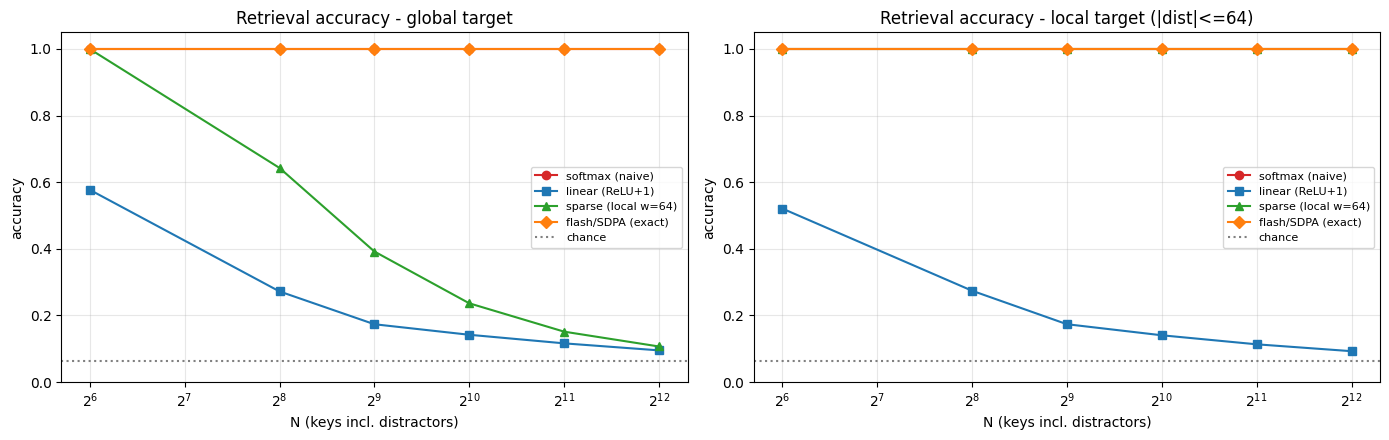

In [10]:
def make_retrieval_task(N, seed, max_dist=None, key_scale=None, noise=None):
    # N keys (unit vectors * key_scale), each bound to one of C balanced classes; value = fixed orthonormal class code (dim DV).
    # Query i is a noisy copy of key tgt[i]; the correct answer is the class of tgt[i]. All other N-1 keys are distractors.
    key_scale, noise, C = key_scale or CFG["KEY_SCALE"], noise if noise is not None else CFG["QUERY_NOISE"], CFG["N_CLASSES"]
    gen = torch.Generator().manual_seed(seed)
    codes = torch.linalg.qr(torch.randn(DV, C, generator=gen))[0].T.contiguous()            # (C,DV), orthonormal rows
    keys  = F.normalize(torch.randn(N, DK, generator=gen), dim=-1)
    cls   = (torch.arange(N) % C)[torch.randperm(N, generator=gen)]                       # balanced classes
    if max_dist is None: tgt = torch.randperm(N, generator=gen)                            # target anywhere in the sequence
    else: tgt = (torch.arange(N) + torch.randint(-max_dist, max_dist + 1, (N,), generator=gen)).clamp(0, N - 1)  # nearby target
    q = F.normalize(keys[tgt] + noise * F.normalize(torch.randn(N, DK, generator=gen), dim=-1), dim=-1)
    T = lambda x: x[None, None].to(DEVICE, torch.float32)
    return T(key_scale * q), T(key_scale * keys), T(codes[cls]), codes.to(DEVICE), cls[tgt].to(DEVICE)

def retrieval_acc(fn, task):
    Q, K, V, codes, label = task
    out = fn(Q, K, V)[0, 0]
    return (F.normalize(out.float(), dim=-1) @ codes.T).argmax(-1).eq(label).float().mean().item()

def bootstrap_ci(x, n=2000, seed=0):                 # 95% CI of the mean, resampling independent tasks
    x = np.asarray(x); rng = np.random.default_rng(seed)
    means = rng.choice(x, size=(n, len(x)), replace=True).mean(1)
    return np.quantile(means, .025), np.quantile(means, .975)

RET = {**METHODS}
rows = []
for mode, md_ in [("global target", None), (f"local target (|dist|<={W})", W)]:
    for N in CFG["RET_LENGTHS"]:
        for sd in range(CFG["RET_TASKS"]):
            task = make_retrieval_task(N, 1000 + sd, max_dist=md_)
            for m, fn in RET.items(): rows.append(dict(mode=mode, N=N, task=sd, method=m, acc=retrieval_acc(fn, task)))
ret = pd.DataFrame(rows)

base = ret[(ret.method==SOFT)&(ret.N==CFG["RET_LENGTHS"][0])&(ret["mode"]=="global target")].acc.mean()
print(f"Baseline sanity check: softmax accuracy at N={CFG['RET_LENGTHS'][0]} = {base:.3f}", "(OK - task is solvable)" if base > .95 else "(WARNING: baseline cannot solve the task - raise KEY_SCALE / lower QUERY_NOISE)")
print(f"Chance level = {1/CFG['N_CLASSES']:.3f}\n")
for mode in ret["mode"].unique():
    print("Retrieval accuracy -", mode); display(ret[ret["mode"]==mode].pivot_table(index="N", columns="method", values="acc")[list(METHODS)].round(3))

# paired differences on shared tasks + non-inferiority test  (Delta = acc_method - acc_softmax)
ni_rows = []
for mode in ret["mode"].unique():
    for N in CFG["RET_LENGTHS"]:
        s = ret[(ret["mode"]==mode)&(ret.N==N)]; ref = s[s.method==SOFT].sort_values("task").acc.values
        for m in [LIN, SPARSE, FLASH]:
            d = s[s.method==m].sort_values("task").acc.values - ref; lo, hi = bootstrap_ci(d)
            ni_rows.append(dict(mode=mode, N=N, method=m, delta=d.mean(), ci_lo=lo, ci_hi=hi, non_inferior=lo > -CFG["DELTA"]))
ni = pd.DataFrame(ni_rows)
print(f"Non-inferiority (needs CI lower bound > -delta = -{CFG['DELTA']}):"); display(ni.round(3))

fig, ax = plt.subplots(1, 2, figsize=(14, 4.5))
for a, mode in zip(ax, ret["mode"].unique()):
    for m in METHODS:
        s = ret[(ret["mode"]==mode)&(ret.method==m)].groupby("N").acc; mu = s.mean()
        a.plot(mu.index, mu.values, marker=STY[m][1], color=STY[m][0], label=m)
    a.axhline(1/CFG["N_CLASSES"], color="gray", ls=":", label="chance"); a.set_xscale("log", base=2); a.set_ylim(0, 1.05)
    a.set_title(f"Retrieval accuracy - {mode}"); a.set_xlabel("N (keys incl. distractors)"); a.set_ylabel("accuracy"); a.grid(alpha=.3); a.legend(fontsize=8)
plt.tight_layout(); plt.show()

In [11]:
def make_favor(m, seed=0):
    Wm = torch.randn(m, DK, generator=torch.Generator().manual_seed(seed)).to(DEVICE)
    def feat(x):
        x = x.float() * DK ** -0.25
        return torch.exp(x @ Wm.T - (x ** 2).sum(-1, keepdim=True) / 2) / math.sqrt(m)
    return feat

N_R = 1024; rows = []
for r in [64, 256, 1024]:
    fav = make_favor(r); fn = lambda Q, K, V, fav=fav: linear_attention(Q, K, V, feat=fav)
    accs = [retrieval_acc(fn, make_retrieval_task(N_R, 1000 + sd)) for sd in range(CFG["RET_TASKS"])]
    rows.append(dict(variant=f"linear FAVOR+ r={r}", state_floats_per_head=r*DV, acc=np.mean(accs)))
accs = [retrieval_acc(linear_attention, make_retrieval_task(N_R, 1000 + sd)) for sd in range(CFG["RET_TASKS"])]
rows.append(dict(variant="linear ReLU+1 (r=64)", state_floats_per_head=DK*DV, acc=np.mean(accs)))
accs = [retrieval_acc(softmax_attention, make_retrieval_task(N_R, 1000 + sd)) for sd in range(CFG["RET_TASKS"])]
rows.append(dict(variant="softmax (exact)", state_floats_per_head=N_R*(DK+DV), acc=np.mean(accs)))
print(f"Retrieval at N={N_R}, global targets. Larger r costs more state/compute (N*r*d_v), so it must be counted in the trade-off:")
display(pd.DataFrame(rows).round(3))

print("\nSignal-strength sweep (query/key norm) at N=1024, global targets:")
rows = []
for ks in [2, 4, 8, 12, 16, 24]:
    for m in [SOFT, LIN, FLASH]:
        rows.append(dict(key_scale=ks, method=m, acc=np.mean([retrieval_acc(METHODS[m], make_retrieval_task(1024, 1000+sd, key_scale=ks)) for sd in range(10)])))
display(pd.DataFrame(rows).pivot(index="key_scale", columns="method", values="acc").round(3))

Retrieval at N=1024, global targets. Larger r costs more state/compute (N*r*d_v), so it must be counted in the trade-off:


,variant,state_floats_per_head,acc
0,linear FAVOR+ r=64,4096,0.101
1,linear FAVOR+ r=256,16384,0.156
2,linear FAVOR+ r=1024,65536,0.267
3,linear ReLU+1 (r=64),4096,0.142
4,softmax (exact),131072,1.000



Signal-strength sweep (query/key norm) at N=1024, global targets:


method,flash/SDPA (exact),linear (ReLU+1),softmax (naive)
key_scale,,,
2,0.324,0.083,0.324
4,0.801,0.109,0.801
8,1.000,0.138,1.000
12,1.000,0.155,1.000
16,1.000,0.162,1.000
24,1.000,0.175,1.000


In [12]:
N_D = 4096 if DEVICE == "cuda" else 1024
rows = []
for d in [16, 32, 64, 128, 256, 512]:
    Q, K, V = make_inputs(N_D, dk=d, dv=d); t = {}
    for m in [SOFT, LIN, FLASH]:
        try:
            for _ in range(2): METHODS[m](Q, K, V)
            t[m] = np.median([time_once(METHODS[m], Q, K, V) for _ in range(5)])
        except RuntimeError as e:
            if not is_oom(e): raise
            t[m] = float("nan"); torch.cuda.empty_cache()
    rows.append(dict(d=d, softmax_ms=t[SOFT], linear_ms=t[LIN], flash_ms=t[FLASH], speedup_vs_softmax=t[SOFT]/t[LIN], speedup_vs_flash=t[FLASH]/t[LIN]))
    del Q, K, V
print(f"N={N_D}, head dim d_k=d_v=r=d.  Softmax ~ N^2*d, linear ~ N*d^2, so linear wins clearly only while N >> d.")
display(pd.DataFrame(rows).round(3))

N=4096, head dim d_k=d_v=r=d.  Softmax ~ N^2*d, linear ~ N*d^2, so linear wins clearly only while N >> d.


,d,softmax_ms,linear_ms,flash_ms,speedup_vs_softmax,speedup_vs_flash
0,16,11.366,0.756,7.680,15.044,10.165
1,32,9.167,0.705,6.642,13.008,9.424
2,64,10.135,0.823,7.442,12.311,9.040
3,128,15.317,1.581,12.272,9.689,7.763
4,256,31.404,3.140,29.565,10.002,9.417
5,512,59.416,7.362,64.497,8.071,8.761


OVERALL COMPARISON  (time slope ~1 => linear in N, ~2 => quadratic; memory slope likewise)


,softmax (naive),linear (ReLU+1),sparse (local w=64),flash/SDPA (exact)
exact softmax?,yes,no (different kernel),no (local only),yes
theory time,O(N^2 d),O(N r d_v),O(N w d),O(N^2 d)
theory memory,O(N^2),O(r d_v) state,O(N w),O(N)
measured time slope,1.81,0.8,0.79,1.74
measured mem slope,1.99,1.0,1.0,1.0
largest N run OK,16384,65536,65536,65536
first OOM at N,32768,none up to 65536,none up to 65536,none up to 65536
faster than naive softmax from N,-,1024,1024,64
faster than flash/SDPA from N,512,1024,1024,-
"rel. error (N=1024, scale 1)",0.0,0.7903,2.1466,0.0


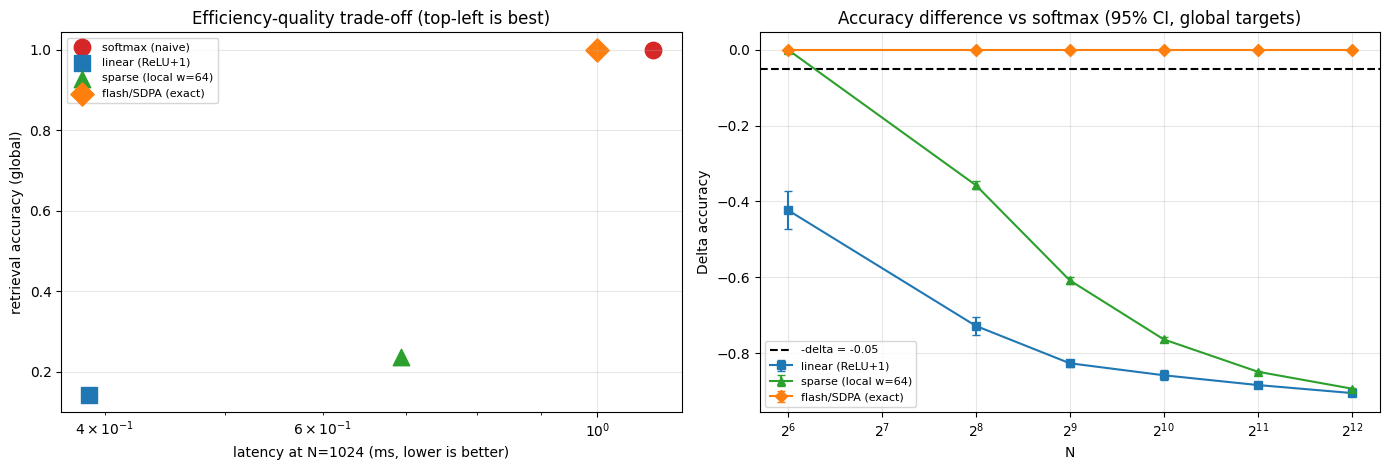

ACCEPTANCE (speedup >= 2.0x vs NAIVE softmax and non-inferior within delta=0.05). Also compare against flash/SDPA in the tables above - the unfavourable control must be kept.


,method,N,mode,speedup_vs_naive,speed_ok,delta_acc,non_inferior,COMBINED_CLAIM
0,linear (ReLU+1),64,global target,0.54,False,-0.423,False,False
1,linear (ReLU+1),64,local target (|dist|<=64),0.54,False,-0.479,False,False
2,linear (ReLU+1),256,global target,0.62,False,-0.728,False,False
3,linear (ReLU+1),256,local target (|dist|<=64),0.62,False,-0.726,False,False
4,linear (ReLU+1),512,global target,0.80,False,-0.826,False,False
5,linear (ReLU+1),512,local target (|dist|<=64),0.80,False,-0.826,False,False
6,linear (ReLU+1),1024,global target,2.86,True,-0.858,False,False
7,linear (ReLU+1),1024,local target (|dist|<=64),2.86,True,-0.859,False,False
8,linear (ReLU+1),2048,global target,6.06,True,-0.884,False,False
9,linear (ReLU+1),2048,local target (|dist|<=64),6.06,True,-0.886,False,False


In [13]:
def slope(m):
    d = eff[(eff.method==m)&(eff.status=="ok")&(eff.N>=1024)]
    return np.polyfit(np.log(d.N), np.log(d.median_ms), 1)[0] if len(d) >= 3 else np.nan
def mem_slope(m):
    d = eff[(eff.method==m)&(eff.status=="ok")&(eff.N>=1024)]
    return np.polyfit(np.log(d.N), np.log(d.extra_mem_mb), 1)[0] if len(d) >= 3 and d.extra_mem_mb.notna().all() else np.nan
def max_ok(m):
    d = eff[(eff.method==m)&(eff.status=="ok")]; return int(d.N.max()) if len(d) else 0
def first_oom(m):
    d = eff[(eff.method==m)&(eff.status=="OOM")]; return int(d.N.min()) if len(d) else "none up to " + str(max(CFG["LENGTHS"]))
def crossover(m, vs):                                    # first N where m is faster than 'vs'
    x = (lat[m] < lat[vs]).fillna(False); return int(x.idxmax()) if x.any() else "none in range"
NR = 1024
theory = {SOFT:("O(N^2 d)","O(N^2)","yes"), LIN:("O(N r d_v)","O(r d_v) state","no (different kernel)"),
          SPARSE:(f"O(N w d)","O(N w)","no (local only)"), FLASH:("O(N^2 d)","O(N)","yes")}
summary = pd.DataFrame({
  "exact softmax?":        {m: theory[m][2] for m in METHODS},
  "theory time":           {m: theory[m][0] for m in METHODS},
  "theory memory":         {m: theory[m][1] for m in METHODS},
  "measured time slope":   {m: round(slope(m), 2) for m in METHODS},
  "measured mem slope":    {m: round(mem_slope(m), 2) for m in METHODS},
  "largest N run OK":      {m: max_ok(m) for m in METHODS},
  "first OOM at N":        {m: first_oom(m) for m in METHODS},
  "faster than naive softmax from N": {m: ("-" if m==SOFT else crossover(m, SOFT)) for m in METHODS},
  "faster than flash/SDPA from N":    {m: ("-" if m==FLASH else crossover(m, FLASH)) for m in METHODS},
  f"rel. error (N={NR if NR in CFG['EVAL_LENGTHS'] else 1024}, scale 1)": {m: (0.0 if m==SOFT else round(err[(err.method==m)&(err.N==1024)&(err.scale==1.0)].rel_err.mean(), 4)) for m in METHODS},
  f"retrieval acc, global, N={NR}": {m: round(ret[(ret["mode"]=="global target")&(ret.N==NR)&(ret.method==m)].acc.mean(), 3) for m in METHODS},
  f"retrieval acc, local, N={NR}":  {m: round(ret[(ret["mode"]!="global target")&(ret.N==NR)&(ret.method==m)].acc.mean(), 3) for m in METHODS},
}).T
print("OVERALL COMPARISON  (time slope ~1 => linear in N, ~2 => quadratic; memory slope likewise)"); display(summary)

# ---- efficiency-quality trade-off plot + acceptance test (speed target AND non-inferiority delta, both required) ----
fig, ax = plt.subplots(1, 2, figsize=(14, 4.8))
for m in METHODS:
    d = eff[(eff.method==m)&(eff.status=="ok")&(eff.N==NR)]
    if len(d):
        acc = ret[(ret["mode"]=="global target")&(ret.N==NR)&(ret.method==m)].acc.mean()
        ax[0].scatter(d.median_ms, acc, s=140, color=STY[m][0], marker=STY[m][1], label=m)
ax[0].set_xscale("log"); ax[0].set_xlabel(f"latency at N={NR} (ms, lower is better)"); ax[0].set_ylabel("retrieval accuracy (global)")
ax[0].set_title("Efficiency-quality trade-off (top-left is best)"); ax[0].grid(alpha=.3); ax[0].legend(fontsize=8)
for m in [LIN, SPARSE, FLASH]:
    s = ni[(ni.method==m)&(ni["mode"]=="global target")]; ax[1].errorbar(s.N, s.delta, yerr=[s.delta-s.ci_lo, s.ci_hi-s.delta], marker=STY[m][1], color=STY[m][0], capsize=3, label=m)
ax[1].axhline(-CFG["DELTA"], color="k", ls="--", label=f"-delta = -{CFG['DELTA']}"); ax[1].set_xscale("log", base=2)
ax[1].set_title("Accuracy difference vs softmax (95% CI, global targets)"); ax[1].set_xlabel("N"); ax[1].set_ylabel("Delta accuracy"); ax[1].grid(alpha=.3); ax[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

acc_rows = []
for m in [LIN, SPARSE, FLASH]:
    for N in CFG["RET_LENGTHS"]:
        if N not in lat.index or pd.isna(lat.loc[N, m]) or pd.isna(lat.loc[N, SOFT]): continue
        spd = lat.loc[N, SOFT] / lat.loc[N, m]
        for mode in ni["mode"].unique():
            r = ni[(ni.method==m)&(ni.N==N)&(ni["mode"]==mode)].iloc[0]
            acc_rows.append(dict(method=m, N=N, mode=mode, speedup_vs_naive=round(spd,2), speed_ok=spd >= CFG["SPEED_TARGET"],
                                 delta_acc=round(r.delta,3), non_inferior=bool(r.non_inferior), COMBINED_CLAIM=bool(spd >= CFG["SPEED_TARGET"] and r.non_inferior)))
acc_df = pd.DataFrame(acc_rows)
print(f"ACCEPTANCE (speedup >= {CFG['SPEED_TARGET']}x vs NAIVE softmax and non-inferior within delta={CFG['DELTA']}). Also compare against flash/SDPA in the tables above - the unfavourable control must be kept.")
display(acc_df)

In [14]:
def fmt(m, vs, N):
    try: return f"{lat.loc[N, vs]/lat.loc[N, m]:.2f}x"
    except Exception: return "n/a"
Nmax = int(lat[LIN].dropna().index.max()); Nref = 4096 if 4096 in lat.index else int(lat.index[-1])
print(f"Under {GPU}, {DTYPE}, B={B}, H={H}, d_k=d_v={DK}, r={DK}, lengths {min(CFG['LENGTHS'])}-{max(CFG['LENGTHS'])}, "
      f"flash backend = {resolve_backend(DTYPE, DEVICE)[0]}:")
print(f" - at N={Nref}, linear was {fmt(LIN, SOFT, Nref)} vs naive softmax and {fmt(LIN, FLASH, Nref)} vs flash/SDPA (>1 = linear faster).")
print(f" - naive softmax first ran out of memory at N={first_oom(SOFT)}; flash/SDPA at {first_oom(FLASH)}; linear at {first_oom(LIN)}; sparse at {first_oom(SPARSE)}.")
g_ = ni[(ni.method==LIN)&(ni["mode"]=="global target")&(ni.N==1024)].iloc[0]
print(f" - linear retrieval accuracy difference at N=1024 (global): {g_.delta:+.3f} [95% CI {g_.ci_lo:+.3f}, {g_.ci_hi:+.3f}] -> "
      f"{'meets' if g_.non_inferior else 'FAILS'} the pre-set delta={CFG['DELTA']}.")
print(" - Applies only to these settings (random data, ReLU+1 map, fixed dims, noncausal, no positional encoding).")
eff.to_csv("efficiency_raw.csv", index=False); err.to_csv("error_raw.csv", index=False); ret.to_csv("retrieval_raw.csv", index=False); ni.to_csv("noninferiority.csv", index=False)
print("Raw results saved: efficiency_raw.csv, error_raw.csv, retrieval_raw.csv, noninferiority.csv  (left sidebar -> Files)")


Under Tesla T4, torch.float32, B=1, H=4, d_k=d_v=64, r=64, lengths 64-65536, flash backend = EFFICIENT (mem-efficient exact):
 - at N=4096, linear was 12.97x vs naive softmax and 11.36x vs flash/SDPA (>1 = linear faster).
 - naive softmax first ran out of memory at N=32768; flash/SDPA at none up to 65536; linear at none up to 65536; sparse at none up to 65536.
 - linear retrieval accuracy difference at N=1024 (global): -0.858 [95% CI -0.871, -0.845] -> FAILS the pre-set delta=0.05.
 - Applies only to these settings (random data, ReLU+1 map, fixed dims, noncausal, no positional encoding).
Raw results saved: efficiency_raw.csv, error_raw.csv, retrieval_raw.csv, noninferiority.csv  (left sidebar -> Files)
